In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
df=pd.read_csv("../data/raw/data.csv")

In [4]:
df.shape
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [13]:
def infer_experience(title):
    if "Senior" in title:
        return np.random.randint(13,20) 
    elif "Junior" in title:
        return np.random.randint(0,7)
    else:
        return np.random.randint(7,13)
df["experience_years"] = df["Job Title"].apply(infer_experience)



In [7]:
ROLE_SKILLS = {
    "Android": ["Java", "Kotlin", "Android SDK"],
    "Backend": ["Python", "Django", "SQL"],
    "Data Scientist": ["Python", "ML", "Pandas"]
}

df["skills"] = df["Job Roles"].map(ROLE_SKILLS)


In [10]:
def infer_company_size(salary):
    if salary < 600000:
        return "Small"
    elif salary < 1200000:
        return "Mid"
    else:
        return "Large"
df["company_size"]=df["Salary"].apply(infer_company_size)

In [14]:
def infer_education(salary, experience):
    
    if salary >= 2000000 and experience >= 8:
        return "PhD"

   
    elif salary >= 800000 and experience >= 3:
        return "Master"

    else:
        return "Bachelor"
    df["education_level"] = df.apply(
    lambda row: infer_education(
        row["Salary"],
        row["experience_years"]
    ),
    axis=1
)


In [16]:
df.head(5)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles,experience_years,skills,company_size
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android,11,"[Java, Kotlin, Android SDK]",Small
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android,11,"[Java, Kotlin, Android SDK]",Small
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android,7,"[Java, Kotlin, Android SDK]",Mid
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android,7,"[Java, Kotlin, Android SDK]",Small
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android,8,"[Java, Kotlin, Android SDK]",Mid


In [17]:
df.head(10)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles,experience_years,skills,company_size
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android,11,"[Java, Kotlin, Android SDK]",Small
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android,11,"[Java, Kotlin, Android SDK]",Small
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android,7,"[Java, Kotlin, Android SDK]",Mid
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android,7,"[Java, Kotlin, Android SDK]",Small
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android,8,"[Java, Kotlin, Android SDK]",Mid
5,4.2,Freelancer,Android Developer,100000,3,Bangalore,Full Time,Android,8,"[Java, Kotlin, Android SDK]",Small
6,3.7,SQUARE N CUBE,Android Developer,192000,3,Bangalore,Full Time,Android,10,"[Java, Kotlin, Android SDK]",Small
7,3.1,Samsung R&D Institute India - Bangalore,Android Developer,400000,3,Bangalore,Full Time,Android,11,"[Java, Kotlin, Android SDK]",Small
8,3.7,DXMinds Technologies,Android Developer,300000,3,Bangalore,Full Time,Android,11,"[Java, Kotlin, Android SDK]",Small
9,3.6,Endeavour Software Technologies,Android Developer,600000,3,Bangalore,Full Time,Android,7,"[Java, Kotlin, Android SDK]",Mid


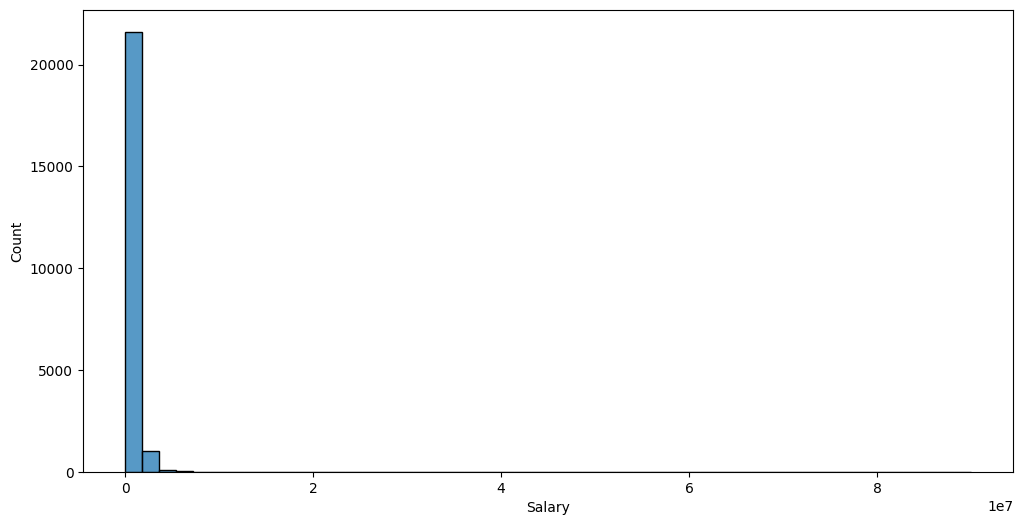

In [19]:
plt.figure(figsize=(12, 6))
sns.histplot(df["Salary"], bins=50)
plt.show()


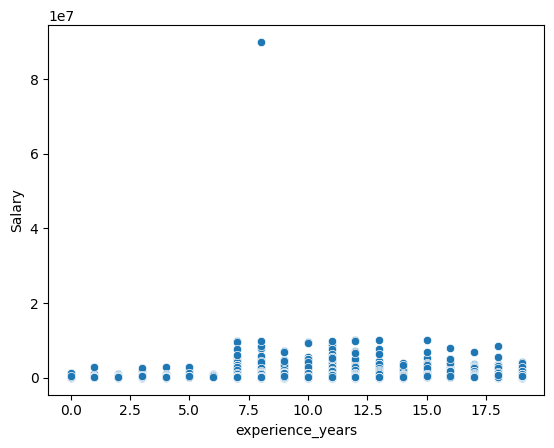

In [20]:
sns.scatterplot(
    x="experience_years",
    y="Salary",
    data=df
)
plt.show()


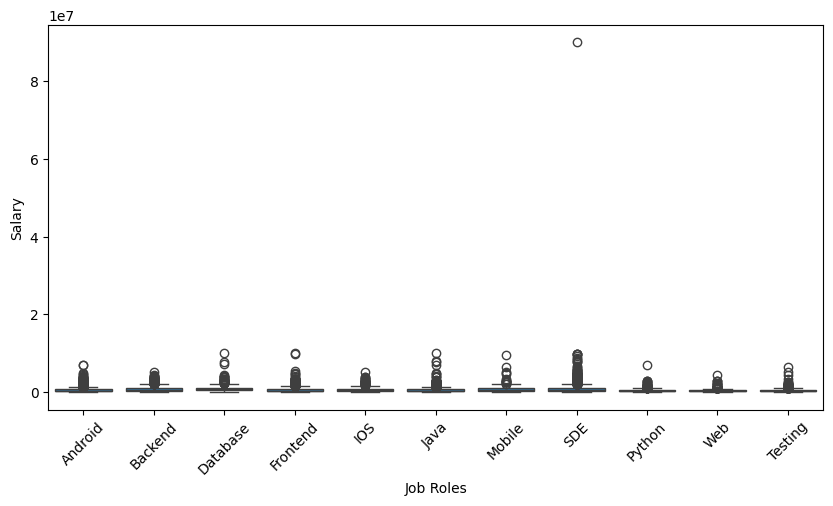

In [21]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x="Job Roles",
    y="Salary",
    data=df
)
plt.xticks(rotation=45)
plt.show()


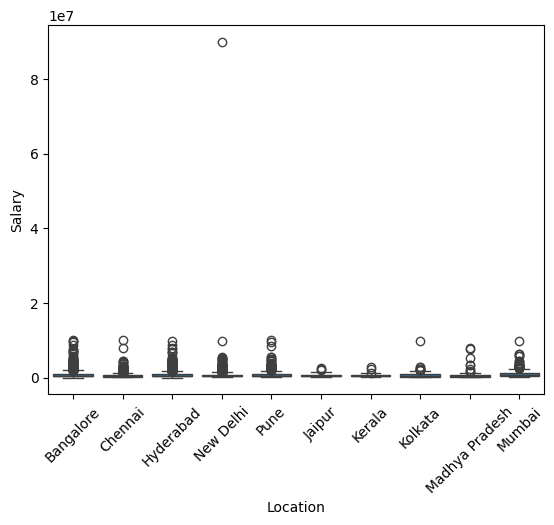

In [22]:
sns.boxplot(
    x="Location",
    y="Salary",
    data=df
)
plt.xticks(rotation=45)
plt.show()


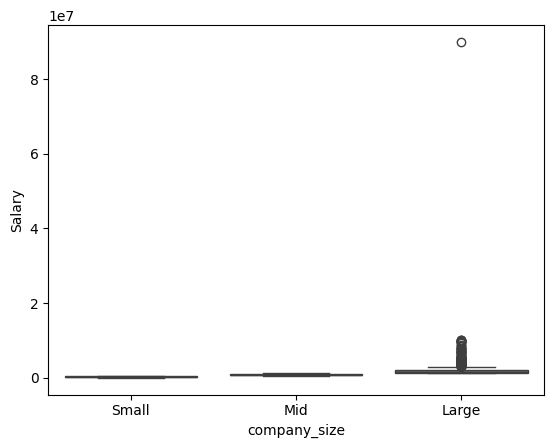

In [23]:
sns.boxplot(
    x="company_size",
    y="Salary",
    data=df
)
plt.show()


In [25]:
df.to_csv(
    "../data/raw/data_after_eda.csv",
    index=False
)
